# LightGBM voor Rister Planning

## 1. Business Understanding

### Bedrijfscontext

Rovecom Groep is een softwarebedrijf in Hoogeveen dat branchespecifieke bedrijfssoftware bouwt. Ik werk bij Rovecom Terra, de business unit die het Rister-platform ontwikkelt voor de groen-, grond- en infrasector. Rister helpt bedrijven hun volledige proces (van veldwerk tot facturatie) te digitaliseren.

Een belangrijk onderdeel van Rister is het planbord: hier plant een planner servicetaken in. Per taak kiest de planner welke medewerker de klus krijgt en schat hij in hoe lang het duurt. Die inschatting is nu volledig handmatig, gebaseerd op ervaring en onderbuikgevoel. Dat kost tijd en leidt tot suboptimale planning: soms krijgt een medewerker een taak waar hij weinig ervaring mee heeft, of wordt de tijdsinschatting flink over- of onderschat.

### Probleemstelling

De vraag is: kan ik met historische planningsdata uit WerkExpert (het oude systeem) twee dingen voorspellen?

1. **Hoeveel uur duurt een servicetaak?** (tijdsvoorspelling)
2. **Welke medewerker past het beste bij deze taak?** (medewerker ranking)

Het systeem moet de planner ondersteunen, niet vervangen. De suggesties verschijnen op het planbord als indicatie. De planner maakt altijd zelf de uiteindelijke keuze. Dit is een bewuste ontwerpkeuze: het gaat om human-in-the-loop, niet om automatische toewijzing.

### Aanpak: twee LightGBM modellen

Ik gebruik twee aparte LightGBM modellen:

1. **LGBMRegressor** voor tijdsvoorspelling: voorspelt de verwachte werktijd in uren
2. **LGBMRanker** voor medewerker ranking: rankt medewerkers op geschiktheid via LambdaRank

Als baseline gebruik ik **Random Forest** (zie `random_forest_rister.ipynb`). LightGBM presteert beter op regressie (MAE 1.25 vs 1.49 uur) en heeft een aantal technische voordelen boven RF:
- Native support voor categorische features (geen OrdinalEncoder nodig zoals bij RF)
- LGBMRanker optimaliseert direct op NDCG via LambdaRank, in plaats van indirect via MSE op suitability score (pointwise RF)
- ONNX export wordt ondersteund, wat nodig is voor deployment in de C# API
- Fine-tuning per klantdatabase is mogelijk via `init_model` (transfer learning — RF ondersteunt dit niet)
- Snellere training en hogere R² (0.64 vs 0.55 bij RF)

### Data

De trainingsdata komt uit WerkExpert: duizenden voltooide servicetaken met gerealiseerde uren. Na filtering en combinatie van alle Rister databases heb ik een dataset van 28.693 rijen met 36 features:
- **11 categorische features**: medewerker ID, bewerkingstype, klant, database, postcode, machine, planningsgroep, etc.
- **25 numerieke features**: coordinaten, cyclische tijdfeatures (dag/maand/week als sin/cos), medewerker-statistieken (gemiddelde tijd, ervaring, snelheid), en hoeveelheid-features (volume, gewicht, stuks)

De data beslaat 15 productieomgevingen van 3 klanten (Diepen, Jennissen, Hulter) over de periode 2021-2025.

### Kwaliteitseisen

| KPI | Streefwaarde | Toelichting |
|-----|-------------|-------------|
| MAE (regressor) | ≤ 0.5 uur (30 min) | Afgesproken met opdrachtgever. Het basismodel haalt dit niet (1.25 uur), maar fine-tuned modellen per omgeving wel. |
| NDCG@3 (ranker) | ≥ 0.90 | Maat voor kwaliteit van de top-3 ranking. Gehaald: 0.9541. |
| API responstijd | < 1.0 seconde | Moet bruikbaar zijn in real-time planning. Gehaald. |
| Top-3 hit rate | Zo hoog mogelijk | Zit de werkelijke medewerker in de top 3 suggesties? |

### Deployment context

De modellen worden geexporteerd als ONNX en draaien in een C# ASP.NET Core API op Azure Container Apps. Training (Python) en inferentie (C#) zijn bewust gescheiden: modellen kunnen onafhankelijk getraind en gedeployd worden zonder de API te wijzigen. Per klantdatabase kan een fine-tuned model worden getraind dat de klant-specifieke patronen beter vangt.

### Ethische overwegingen

Dit systeem raakt aan privacy en eerlijke behandeling van medewerkers. Drie kernprincipes:
- **Geen prestatiebeoordelingen**: de data wordt niet gebruikt voor functioneringsgesprekken
- **Geanonimiseerde ID's**: alleen medewerker-ID's in de API response, geen namen
- **Presentatie als indicatie**: de UI toont suggesties, geen harde labels zoals "te langzaam"

## Stap 1: Imports

Ik gebruik de volgende libraries:
- `lightgbm`: de LGBMRegressor en LGBMRanker modellen
- `optuna`: hyperparameter tuning met Bayesian optimization
- `sklearn`: train/test split en evaluatiemetrics (MAE, RMSE, R2, NDCG)
- `mlflow`: experiment tracking, model logging en model registry
- `onnxmltools` + `onnxruntime`: ONNX export voor C# deployment

In [1]:
import json
import os

import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    ndcg_score,
    r2_score,
)
from sklearn.model_selection import train_test_split

print(f"LightGBM: {lgb.__version__}")

LightGBM: 4.6.0


### MLflow configuratie

Ik log alle experimenten naar een lokale MLflow server. Dit maakt het makkelijk om hyperparameters, metrics en modellen te vergelijken tussen runs. Het experiment heet `rister-lightgbm-v1-plushoeveelheid_inc_finetune` omdat deze versie de hoeveelheid-features (volume, gewicht, stuks, etc.) meeneemt en fine-tuning per database bevat.

In [2]:
# MLflow configuratie
MLFLOW_TRACKING_URI = "http://127.0.0.1:5002"
MLFLOW_EXPERIMENT = "rister-lightgbm-v1-plushoeveelheid_inc_finetune"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow: {mlflow.get_tracking_uri()}")

MLflow: http://127.0.0.1:5002


## Stap 2: Data laden

Ik laad de gecombineerde dataset van alle Rister databases. Er zit een kolomnaam mismatch in de CSV (`aarURENVERANTW_MEDID` in plaats van `URENVERANTW_MEDID`) die ik hier corrigeer.

In [3]:
df = pd.read_csv("dataframe_gecombineerd.csv")
# Fix kolomnaam mismatch: CSV gebruikt 'aar' prefix
df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)
print(f"Rijen: {len(df)}, Kolommen: {len(df.columns)}")
df.head()

Rijen: 28693, Kolommen: 41


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_91507/2184696128.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataframe_gecombineerd.csv")


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
3,745,966,NaN,3072.0,PVC verloopr 110x125 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
4,745,947,NaN,3072.0,PVC oversch mof 110 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.105263,0.042105


De dataset bevat 28.693 rijen en 41 kolommen. De DtypeWarning voor mixed types komt doordat sommige kolommen zowel strings als numerieke waarden bevatten. Dit los ik op in de data voorbereiding door expliciet types te casten.

## Stap 3: Features en targets

Ik splits de features in twee groepen:

**Categorische features (11)**: identificatoren zoals medewerker (`URENVERANTW_MEDID`), bewerking (`BEWERKING_ID`), klant (`RELATIE_ID`), database (`con`), en beschrijvingen zoals `DIENST_ART_OMS` en `MACH_OMS`. LightGBM kan hier direct mee werken zonder encoding.

**Numerieke features (25)**: coordinaten (lat/lon), cyclische tijdfeatures (dag/maand/week als sin/cos), medewerker-statistieken (gemiddelde tijd, ervaring, snelheid per bewerking/klant), en hoeveelheid-features (volume, gewicht, stuks, aanwezig, baal).

**Targets**:
- `REAL_WORKED_TIME`: de werkelijke tijd in uren (voor de regressor)
- `suitability_score`: een score van 0-1 die aangeeft hoe geschikt een medewerker is voor een taak (voor de ranker)

In [4]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

NUMERICAL = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klant_gem_tijd",
    "med_bewerking_gem_tijd",
    "med_totaal_opdrachten",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]

FEATURES = CATEGORICAL + NUMERICAL
TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"

## Stap 4: Data voorbereiden

LightGBM kan categorische features native afhandelen als ze het `category` dtype hebben. Ik hoef dus geen LabelEncoder of one-hot encoding te gebruiken.

**Missing values strategie**:
- Categorisch: vul met `"ONBEKEND"` en zet om naar `category` dtype. LightGBM behandelt dit als een aparte categorie.
- Numeriek: forceer naar float met `pd.to_numeric(errors="coerce")` en vul missende waarden met 0. Dit is een conservatieve keuze; voor features als lat/lon zou een mediaan beter zijn, maar de meeste numerieke features hebben weinig missende waarden.

In [5]:
# Categorische kolommen: fillna + category dtype
for col in CATEGORICAL:
    df[col] = df[col].fillna("ONBEKEND").astype("category")

# Numerieke kolommen: fillna
for col in NUMERICAL:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Categorische cardinaliteiten:")
for col in CATEGORICAL:
    print(f"  {col:30s} → {df[col].nunique():5d}")

Categorische cardinaliteiten:
  URENVERANTW_MEDID              →   459
  BEWERKING_ID                   →    83
  DIENST_ART_ID                  →   709
  RELATIE_ID                     →  2174
  REL_POSTCODE                   →  1190
  DIENST_ART_OMS                 →   544
  MACH_OMS                       →   117
  con                            →    51
  bron                           →     2
  EquipmentGroupTypes            →     4
  planninggroupsname             →    20


De cardinaliteiten laten zien dat sommige features erg breed zijn: `RELATIE_ID` heeft 2.174 unieke waarden en `REL_POSTCODE` 1.190. Dit is geen probleem voor LightGBM; het splitst categorische features op basis van de histogram-methode en kan hoge cardinaliteit goed aan. Features met lage cardinaliteit zoals `bron` (2) en `EquipmentGroupTypes` (4) zijn makkelijker te leren maar minder informatief op zichzelf.

## Stap 5: Train/validatie split

Ik gebruik een 80/20 split met `random_state=42` voor reproduceerbaarheid. Dit is een simpele random split; een tijdsgebaseerde split zou realistischer zijn voor productie, maar voor het vergelijken van modellen is random voldoende.

In [6]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = df.loc[train_idx, FEATURES]
X_val = df.loc[val_idx, FEATURES]

y_time_train = df.loc[train_idx, TARGET_TIME].values
y_time_val = df.loc[val_idx, TARGET_TIME].values
y_rank_train = df.loc[train_idx, TARGET_RANK].values
y_rank_val = df.loc[val_idx, TARGET_RANK].values

print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

Train: 22,954  |  Val: 5,739


## Stap 6: Data verkennen

Ik bekijk de verdelingen van de twee targets en hun onderlinge relatie. Dit geeft inzicht in wat de modellen moeten leren en of er uitschieters zijn.

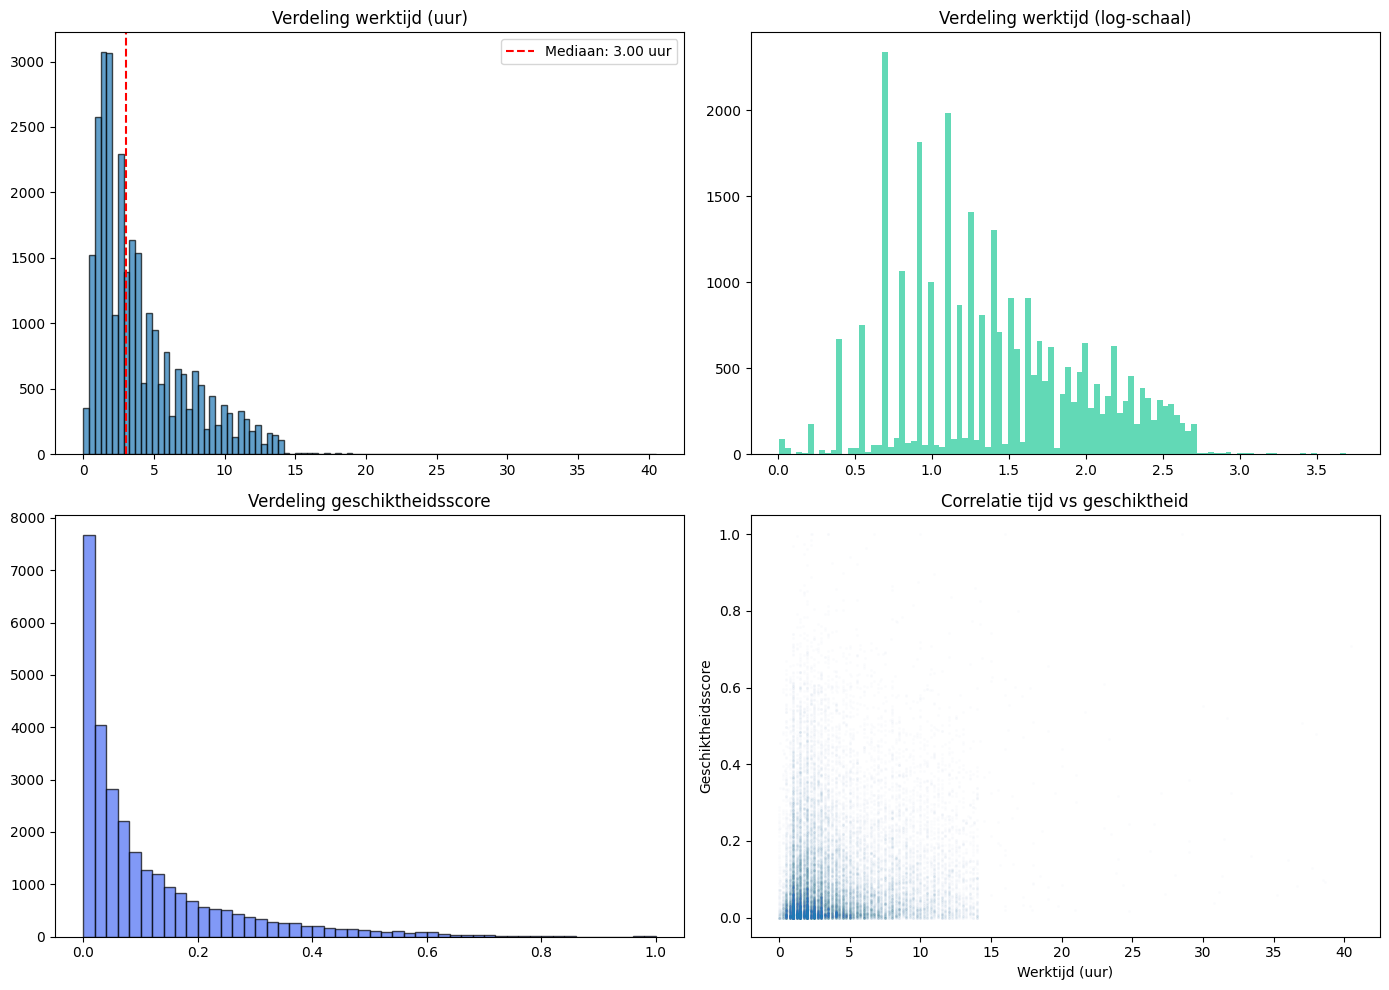

Correlatie tijd-geschiktheid: 0.056


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df[TARGET_TIME], bins=100, edgecolor="black", alpha=0.7)
axes[0, 0].axvline(
    df[TARGET_TIME].median(),
    color="red",
    ls="--",
    label=f"Mediaan: {df[TARGET_TIME].median():.2f} uur",
)
axes[0, 0].set_title("Verdeling werktijd (uur)")
axes[0, 0].legend()

axes[0, 1].hist(np.log1p(df[TARGET_TIME].clip(lower=0)), bins=100, alpha=0.7, color="#20c997")
axes[0, 1].set_title("Verdeling werktijd (log-schaal)")

axes[1, 0].hist(df[TARGET_RANK], bins=50, edgecolor="black", alpha=0.7, color="#4c6ef5")
axes[1, 0].set_title("Verdeling geschiktheidsscore")

axes[1, 1].scatter(df[TARGET_TIME], df[TARGET_RANK], alpha=0.01, s=2)
axes[1, 1].set_xlabel("Werktijd (uur)")
axes[1, 1].set_ylabel("Geschiktheidsscore")
axes[1, 1].set_title("Correlatie tijd vs geschiktheid")

plt.tight_layout()
plt.show()

corr = df[[TARGET_TIME, TARGET_RANK]].corr().iloc[0, 1]
print(f"Correlatie tijd-geschiktheid: {corr:.3f}")

### Wat valt op

De verdeling van `REAL_WORKED_TIME` is sterk rechtsscheef: de meeste taken duren kort, maar er zijn uitschieters tot ver boven de 10 uur. Op log-schaal is de verdeling iets normaler, wat aangeeft dat Huber loss (robuust tegen outliers) een goede keuze is voor de regressor.

De `suitability_score` is sterk links-geconcentreerd: de meeste scores zijn laag (0-0.2). Dit komt omdat de meeste medewerker-taak combinaties niet ideaal zijn; slechts een klein deel scoort hoog.

De correlatie tussen tijd en geschiktheid is 0.056, dus vrijwel nul. Dit bevestigt dat het twee onafhankelijke voorspeltaken zijn en dat twee aparte modellen (regressor + ranker) de juiste aanpak is.

## Stap 7: LGBMRegressor - Tijdsvoorspelling

### Hyperparameter tuning met Optuna

Ik gebruik Optuna voor Bayesian hyperparameter optimization met 50 trials. Het objectief is het minimaliseren van de validatie MAE.

**Search space onderbouwing**:
- `n_estimators` (200-2000): genoeg range om zowel underfitting als overfitting te vangen, met early stopping als vangnet
- `learning_rate` (0.01-0.3): standaard range voor gradient boosting. Lager = stabieler maar langzamer
- `max_depth` (4-12): diepere bomen vangen meer interacties maar overfitten sneller
- `num_leaves` (31-500): LightGBM groeit leaf-wise, dus dit is de primaire complexiteitsparameter
- `min_child_samples` (5-50): voorkomt dat bladeren op te weinig samples splitsen
- `subsample` en `colsample_bytree` (0.5-1.0): stochastic gradient boosting voor regularisatie
- `reg_alpha` en `reg_lambda` (0.0-1.0): L1/L2 regularisatie op de blad-gewichten

Het script checkt eerst MLflow voor eerdere tuning runs. Als die bestaan, hergebruikt het de beste parameters in plaats van opnieuw te tunen.

In [8]:
# Probeer beste regressor params op te halen uit MLflow,
# anders draai Optuna tuning.
from mlflow.tracking import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)

client = MlflowClient()
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

reg_runs = []
if experiment:
    reg_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'reg_trial_%'",
        order_by=["metrics.val_mae ASC"],
        max_results=1,
    )

if reg_runs:
    # Params uit MLflow laden
    best_run = reg_runs[0]
    p = best_run.data.params
    best_reg_params = {
        "objective": p["objective"],
        "metric": p["metric"],
        "verbosity": int(p["verbosity"]),
        "n_jobs": int(p["n_jobs"]),
        "n_estimators": int(p["n_estimators"]),
        "learning_rate": float(p["learning_rate"]),
        "max_depth": int(p["max_depth"]),
        "num_leaves": int(p["num_leaves"]),
        "min_child_samples": int(p["min_child_samples"]),
        "subsample": float(p["subsample"]),
        "colsample_bytree": float(p["colsample_bytree"]),
        "reg_alpha": float(p["reg_alpha"]),
        "reg_lambda": float(p["reg_lambda"]),
    }
    print(f"Beste regressor trial uit MLflow: {best_run.info.run_name}")
    print(f"Val MAE: {best_run.data.metrics['val_mae']:.4f}")
    print(f"Params: {best_reg_params}")

else:
    # Geen eerdere runs gevonden — Optuna draaien
    print("Geen regressor trials in MLflow, start Optuna tuning...")

    def objective_regressor(trial):
        params = {
            "objective": "huber",
            "metric": "mae",
            "verbosity": -1,
            "n_jobs": -1,
            "n_estimators": trial.suggest_int("n_estimators", 200, 2000, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        }

        with mlflow.start_run(run_name=f"reg_trial_{trial.number}", nested=True):
            mlflow.log_params(params)

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train,
                y_time_train,
                eval_set=[(X_val, y_time_val)],
                categorical_feature=CATEGORICAL,
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            preds = model.predict(X_val)
            mae = mean_absolute_error(y_time_val, preds)
            rmse = np.sqrt(mean_squared_error(y_time_val, preds))

            mlflow.log_metrics(
                {
                    "val_mae": mae,
                    "val_rmse": rmse,
                    "best_iteration": model.best_iteration_,
                }
            )

        return mae

    with mlflow.start_run(run_name="optuna_regressor"):
        study_reg = optuna.create_study(direction="minimize", study_name="lgbm_regressor")
        study_reg.optimize(objective_regressor, n_trials=50, show_progress_bar=True)

    best_reg_params = study_reg.best_params
    best_reg_params.update({"objective": "huber", "metric": "mae", "verbosity": -1, "n_jobs": -1})

    print(f"\nBeste MAE: {study_reg.best_value:.4f} uur ({study_reg.best_value * 60:.1f} min)")
    print(f"Params: {best_reg_params}")

Beste regressor trial uit MLflow: reg_trial_28
Val MAE: 1.2490
Params: {'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1, 'n_estimators': 1300, 'learning_rate': 0.08243656564786471, 'max_depth': 12, 'num_leaves': 211, 'min_child_samples': 19, 'subsample': 0.7157551527215977, 'colsample_bytree': 0.791569651325948, 'reg_alpha': 1.2871758769518114e-06, 'reg_lambda': 4.6586991226174855e-05}


### Train het finale regressie model

Ik train het finale model met de beste hyperparameters uit Optuna. Een paar keuzes:

- **Huber loss** (`objective="huber"`): combineert MSE voor kleine fouten met MAE voor grote fouten. Dit maakt het model robuust tegen de uitschieters in werktijd die ik in de data verkenning zag.
- **Early stopping** (patience=50): stopt als de validatie MAE 50 rondes niet verbetert, om overfitting te voorkomen.
- `categorical_feature=CATEGORICAL`: vertelt LightGBM welke kolommen categorisch zijn, zodat het de optimale split-strategie gebruikt.

In [9]:
# Train final regressor met beste params
try:
    best_reg_params = study_reg.best_params
except NameError:
    pass  # best_reg_params is al geladen uit MLflow
best_reg_params.update({"objective": "huber", "metric": "mae", "verbosity": -1, "n_jobs": -1})

reg_model = lgb.LGBMRegressor(**best_reg_params)
reg_model.fit(
    X_train,
    y_time_train,
    eval_set=[(X_val, y_time_val)],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print(f"Beste iteratie: {reg_model.best_iteration_}")

[100]	valid_0's l1: 1.42088
[200]	valid_0's l1: 1.35032
[300]	valid_0's l1: 1.32236
[400]	valid_0's l1: 1.3003
[500]	valid_0's l1: 1.28254
[600]	valid_0's l1: 1.27525
[700]	valid_0's l1: 1.26864
[800]	valid_0's l1: 1.26253
[900]	valid_0's l1: 1.25952
[1000]	valid_0's l1: 1.25781
[1100]	valid_0's l1: 1.25394
[1200]	valid_0's l1: 1.24959
Beste iteratie: 1225


De MAE daalt consistent van 1.42 (na 100 iteraties) naar 1.25 (bij iteratie 1225). Early stopping stopt bij 1225 van de maximaal 2000 iteraties, wat aangeeft dat het model nog niet volledig geconvergeerd is maar de verbeteringen marginaal worden. De MAE van 1.25 uur betekent dat de voorspelling gemiddeld 1 uur en 15 minuten afwijkt van de werkelijke werktijd.

## Stap 8: LGBMRanker - Geschiktheidsranking

### Waarom LambdaRank?

Voor de ranking gebruik ik `LGBMRanker` met LambdaRank. Het verschil met een gewone regressor op de suitability score is dat LambdaRank direct optimaliseert op de rangorde (NDCG), niet op de absolute waarde. Het maakt niet uit of de score 0.8 of 0.6 is, zolang de juiste medewerker bovenaan staat.

### Groepering

LambdaRank werkt met groepen: binnen elke groep leert het model de juiste volgorde. Ik groepeer op `(con, BEWERKING_ID)`, dus per database en bewerkingstype. De logica is dat de ranking van medewerkers verschilt per type taak en per klantdatabase.

### Relevance labels

De continue suitability score (0-1) wordt omgezet naar 5 discrete relevance labels (0-4) via bins van 0.2. Dit is nodig omdat LambdaRank met discrete relevantieniveaus werkt.

In [10]:
# Groepering voor LambdaRank
# Elke groep = rijen met dezelfde (con, BEWERKING_ID) combinatie
GROUP_COLS = ["con", "BEWERKING_ID"]

df["_group_key"] = df[GROUP_COLS].astype(str).agg("__".join, axis=1)

# LGBMRanker verwacht integer relevance labels.
# Zet suitability_score (0.0 - 1.0) om naar 0-4 relevance levels.
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df["_rank_label"] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

print("Relevance label verdeling:")
print(df["_rank_label"].value_counts().sort_index())

# Sorteer op groep zodat de group sizes kloppen
df_sorted = df.sort_values("_group_key").reset_index(drop=True)

# Split op groepniveau
groups = df_sorted.groupby("_group_key")
group_keys = list(groups.groups.keys())

train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)
train_keys_set = set(train_keys)
val_keys_set = set(val_keys)

train_mask = df_sorted["_group_key"].isin(train_keys_set)
val_mask = df_sorted["_group_key"].isin(val_keys_set)

X_rank_train = df_sorted.loc[train_mask, FEATURES]
X_rank_val = df_sorted.loc[val_mask, FEATURES]
y_rank_train_sorted = df_sorted.loc[train_mask, "_rank_label"].values
y_rank_val_sorted = df_sorted.loc[val_mask, "_rank_label"].values

# Bewaar ook de originele float scores voor evaluatie
y_rank_train_float = df_sorted.loc[train_mask, TARGET_RANK].values
y_rank_val_float = df_sorted.loc[val_mask, TARGET_RANK].values

# Group sizes
train_groups = df_sorted.loc[train_mask].groupby("_group_key").size().values
val_groups = df_sorted.loc[val_mask].groupby("_group_key").size().values

print(f"\nRank train: {len(X_rank_train):,} rijen in {len(train_groups):,} groepen")
print(f"Rank val:   {len(X_rank_val):,} rijen in {len(val_groups):,} groepen")
print(f"Gemiddelde groepsgrootte: {train_groups.mean():.1f}")

Relevance label verdeling:
_rank_label
0    23299
1     3789
2     1257
3      303
4       45
Name: count, dtype: int64

Rank train: 20,918 rijen in 224 groepen
Rank val:   7,775 rijen in 56 groepen
Gemiddelde groepsgrootte: 93.4


### Class imbalance in relevance labels

De verdeling is sterk scheef: 81% van de labels is 0 (laagste relevantie) en slechts 0.16% is 4 (hoogste). Dit is logisch: de meeste medewerker-taak combinaties zijn niet ideaal. Voor NDCG is dit geen groot probleem omdat NDCG focust op de top van de ranking, niet op de gehele verdeling.

De gemiddelde groepsgrootte is 93.4 medewerkers per groep, met 224 traingroepen en 56 validatiegroepen. De groepsgrootte varieert sterk, wat impact heeft op de betrouwbaarheid van NDCG per groep.

### Optuna tuning voor de ranker

Dezelfde search space als de regressor, maar nu met `objective="lambdarank"` en NDCG@3 en NDCG@5 als evaluatiemetrics.

In [11]:
# Probeer beste ranker params op te halen uit MLflow,
# anders draai Optuna tuning.
rank_runs = []
if experiment:
    rank_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'rank_trial_%'",
        order_by=["metrics.val_ndcg_at_3 DESC"],
        max_results=1,
    )

if rank_runs:
    best_run = rank_runs[0]
    p = best_run.data.params
    best_rank_params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [3, 5],
        "verbosity": -1,
        "n_jobs": -1,
        "n_estimators": int(p["n_estimators"]),
        "learning_rate": float(p["learning_rate"]),
        "max_depth": int(p["max_depth"]),
        "num_leaves": int(p["num_leaves"]),
        "min_child_samples": int(p["min_child_samples"]),
        "subsample": float(p["subsample"]),
        "colsample_bytree": float(p["colsample_bytree"]),
        "reg_alpha": float(p["reg_alpha"]),
        "reg_lambda": float(p["reg_lambda"]),
    }
    print(f"Beste ranker trial uit MLflow: {best_run.info.run_name}")
    print(f"Val NDCG@3: {best_run.data.metrics['val_ndcg_at_3']:.4f}")
    print(f"Params: {best_rank_params}")

else:
    print("Geen ranker trials in MLflow, start Optuna tuning...")

    def objective_ranker(trial):
        params = {
            "objective": "lambdarank",
            "metric": "ndcg",
            "ndcg_eval_at": [3, 5],
            "verbosity": -1,
            "n_jobs": -1,
            "n_estimators": trial.suggest_int("n_estimators", 200, 2000, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        }

        with mlflow.start_run(run_name=f"rank_trial_{trial.number}", nested=True):
            mlflow.log_params({k: v for k, v in params.items() if k != "ndcg_eval_at"})

            model = lgb.LGBMRanker(**params)
            model.fit(
                X_rank_train,
                y_rank_train_sorted,
                group=train_groups,
                eval_set=[(X_rank_val, y_rank_val_sorted)],
                eval_group=[val_groups],
                categorical_feature=CATEGORICAL,
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            preds = model.predict(X_rank_val)

            ndcg_scores = []
            offset = 0
            for size in val_groups:
                if size < 2:
                    offset += size
                    continue
                g_true = y_rank_val_float[offset : offset + size]
                g_pred = preds[offset : offset + size]
                ndcg_scores.append(ndcg_score([g_true], [g_pred], k=3))
                offset += size

            mean_ndcg = np.mean(ndcg_scores)
            mlflow.log_metrics(
                {
                    "val_ndcg_at_3": mean_ndcg,
                    "best_iteration": model.best_iteration_,
                }
            )

        return mean_ndcg

    with mlflow.start_run(run_name="optuna_ranker"):
        study_rank = optuna.create_study(direction="maximize", study_name="lgbm_ranker")
        study_rank.optimize(objective_ranker, n_trials=50, show_progress_bar=True)

    best_rank_params = study_rank.best_params
    best_rank_params.update(
        {
            "objective": "lambdarank",
            "metric": "ndcg",
            "ndcg_eval_at": [3, 5],
            "verbosity": -1,
            "n_jobs": -1,
        }
    )

    print(f"\nBeste NDCG@3: {study_rank.best_value:.4f}")
    print(f"Params: {best_rank_params}")

Beste ranker trial uit MLflow: rank_trial_48
Val NDCG@3: 0.9541
Params: {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [3, 5], 'verbosity': -1, 'n_jobs': -1, 'n_estimators': 300, 'learning_rate': 0.20007286208504532, 'max_depth': 4, 'num_leaves': 182, 'min_child_samples': 31, 'subsample': 0.8635007193993606, 'colsample_bytree': 0.8220805753759625, 'reg_alpha': 6.202025540048426e-06, 'reg_lambda': 1.1304515733432721e-05}


### Train het finale ranking model

In [12]:
# Train final ranker
try:
    best_rank_params = study_rank.best_params
except NameError:
    pass  # best_rank_params is al geladen uit MLflow
best_rank_params.update(
    {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [3, 5],
        "verbosity": -1,
        "n_jobs": -1,
    }
)

rank_model = lgb.LGBMRanker(**best_rank_params)
rank_model.fit(
    X_rank_train,
    y_rank_train_sorted,
    group=train_groups,
    eval_set=[(X_rank_val, y_rank_val_sorted)],
    eval_group=[val_groups],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print(f"Beste iteratie: {rank_model.best_iteration_}")

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[100]	valid_0's ndcg@3: 0.928367	valid_0's ndcg@5: 0.938424
[200]	valid_0's ndcg@3: 0.950497	valid_0's ndcg@5: 0.954567
Beste iteratie: 231


De NDCG@3 stijgt snel van 0.928 (na 100 iteraties) naar 0.950 (bij iteratie 200). Early stopping stopt al bij iteratie 231 van de maximale 300, wat aangeeft dat het model snel convergeert. Een validatie-NDCG@3 van 0.954 is een sterke score; perfect zou 1.0 zijn. De variatie per groep die ik later in de evaluatie zie, geeft aan dat het model op sommige groepen iets beter werkt dan op andere.

## Stap 9: Evaluatie - Tijdsvoorspelling

Ik evalueer het regressie model op de validatieset met drie metrics:
- **MAE**: gemiddelde absolute fout in uren (primaire metric)
- **RMSE**: wortel van de gemiddelde kwadratische fout (gevoeliger voor uitschieters)
- **R2**: hoeveel variantie het model verklaart (1.0 = perfect, 0.0 = geen verklaring)

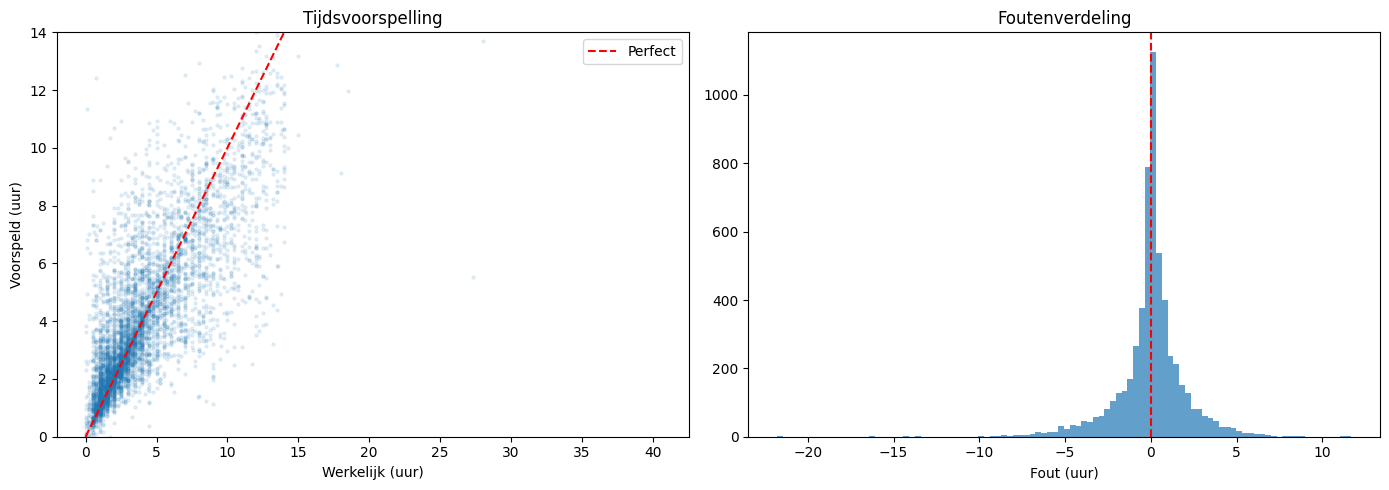

MAE:  1.2490 uur (74.9 min)
RMSE: 1.9767 uur (118.6 min)
R2:   0.6392
KPI:  MAE > 30 min


In [13]:
y_pred_time = reg_model.predict(X_val)

mae = mean_absolute_error(y_time_val, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_time_val, y_pred_time))
r2 = r2_score(y_time_val, y_pred_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_time_val, y_pred_time, alpha=0.1, s=5)
axes[0].plot([0, y_time_val.max()], [0, y_time_val.max()], "r--", label="Perfect")
axes[0].set_xlabel("Werkelijk (uur)")
axes[0].set_ylabel("Voorspeld (uur)")
axes[0].set_ylim(0, 14)
axes[0].set_title("Tijdsvoorspelling")
axes[0].legend()

errors = y_pred_time - y_time_val
axes[1].hist(errors, bins=100, alpha=0.7)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Foutenverdeling")
axes[1].set_xlabel("Fout (uur)")

plt.tight_layout()
plt.show()

print(f"MAE:  {mae:.4f} uur ({mae * 60:.1f} min)")
print(f"RMSE: {rmse:.4f} uur ({rmse * 60:.1f} min)")
print(f"R2:   {r2:.4f}")
print(f"KPI:  MAE {'<= 30 min' if mae * 60 <= 30 else '> 30 min'}")

### Interpretatie regressie resultaten

| Metric | Waarde | Betekenis |
|--------|--------|-----------|
| MAE | 1.2490 uur | Gemiddeld 1 uur en 15 minuten afwijking |
| RMSE | 1.9767 uur | Uitschieters trekken dit omhoog (bijna 1.6x de MAE) |
| R2 | 0.6392 | Het model verklaart 64% van de variantie |

De MAE van 1.25 uur is bruikbaar voor planning, maar niet super nauwkeurig. De R2 van 0.64 is redelijk: er is nog 36% onverklaarde variantie. Het verschil tussen MAE en RMSE (factor 1.6) bevestigt dat er uitschieters zijn waar het model flink naast zit, wat de keuze voor Huber loss achteraf rechtvaardigt.

De vorige versie in het model registry had een MAE van 1.2523, dus deze run is een marginale verbetering (0.003 uur beter).

### Error Analysis: Fouten per werksoort, omgeving en duurcategorie

De overall MAE van 1.25 uur zegt weinig over *waar* het model goed of slecht presteert. 
Een uitsplitsing per werksoort (DIENST_ART_OMS), omgeving (con) en duurcategorie 
geeft inzicht in structurele zwaktes die het TO moet adresseren.

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_91507/571001545.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("DIENST_ART_OMS")


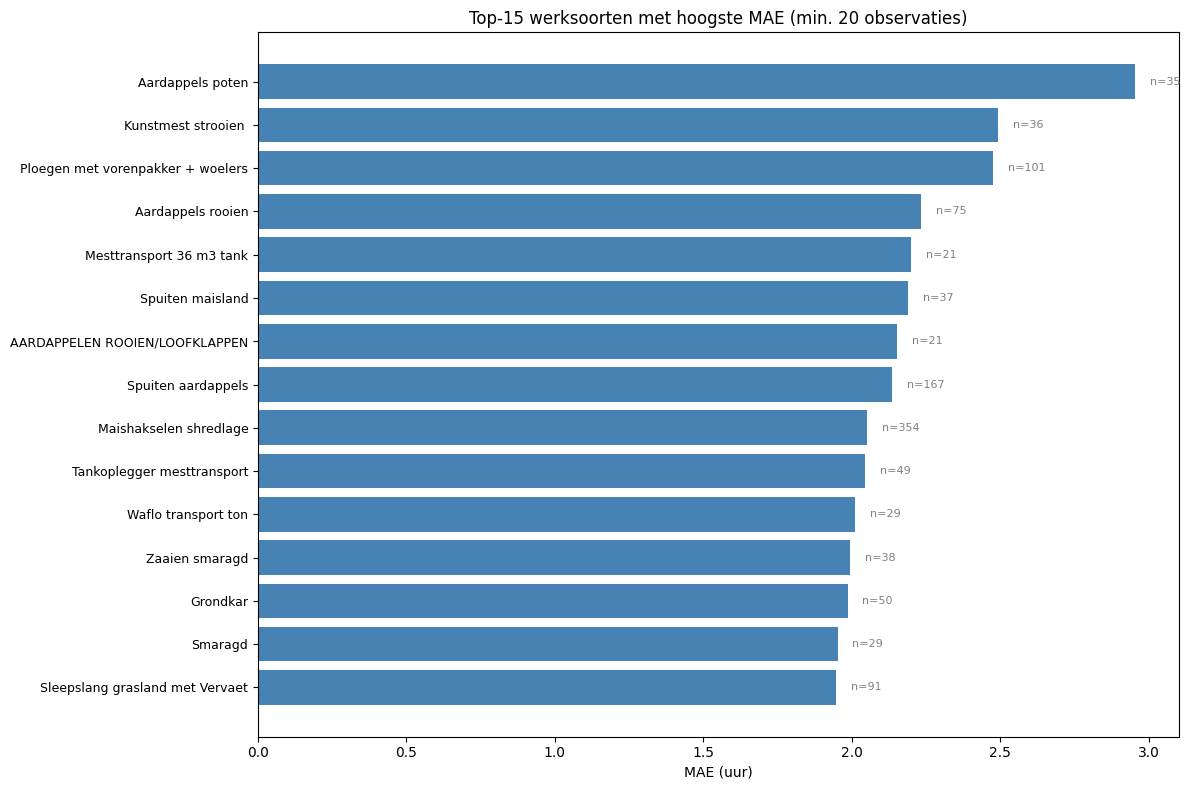

Werksoorten met MAE > 2 uur: 11
Werksoorten geanalyseerd: 51 (>= 20 obs)


,mae,rmse,count
DIENST_ART_OMS,,,
Aardappels poten,2.953573,3.566628,35
Kunstmest strooien,2.493124,3.021808,36
Ploegen met vorenpakker + woelers,2.475192,3.106184,101
Aardappels rooien,2.232573,2.741427,75
Mesttransport 36 m3 tank,2.199121,2.644238,21
Spuiten maisland,2.190384,2.856151,37
AARDAPPELEN ROOIEN/LOOFKLAPPEN,2.152675,2.632648,21
Spuiten aardappels,2.134273,2.815098,167
Maishakselen shredlage,2.052260,2.622333,354


In [14]:
# --- Error analysis per werksoort (DIENST_ART_OMS) ---
residuals = y_pred_time - y_time_val
val_meta = df.loc[val_idx, ["DIENST_ART_OMS", "con"]].reset_index(drop=True)

error_by_dienst = (
    val_meta.assign(abs_error=np.abs(residuals), residual=residuals)
    .groupby("DIENST_ART_OMS")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: np.sqrt((x**2).mean())),
        count=("abs_error", "count"),
    )
    .query("count >= 20")
    .sort_values("mae", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
top15 = error_by_dienst.head(15)
bars = ax.barh(range(len(top15)), top15["mae"], color="steelblue")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=9)
for i, (mae_val, count) in enumerate(zip(top15["mae"], top15["count"])):
    ax.text(mae_val + 0.05, i, f"n={count}", va="center", fontsize=8, color="gray")
ax.set_xlabel("MAE (uur)")
ax.set_title("Top-15 werksoorten met hoogste MAE (min. 20 observaties)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Werksoorten met MAE > 2 uur: {len(error_by_dienst[error_by_dienst.mae > 2])}")
print(f"Werksoorten geanalyseerd: {len(error_by_dienst)} (>= 20 obs)")
error_by_dienst.head(10)

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_91507/1681241438.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("con")


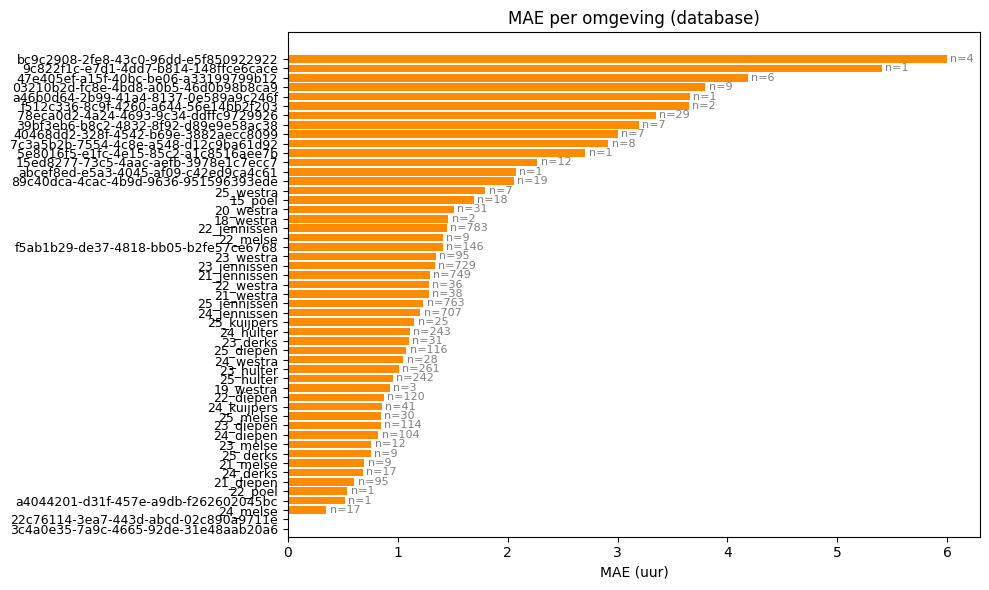

,mae,rmse,count
con,,,
bc9c2908-2fe8-43c0-96dd-e5f850922922,5.998742,7.952657,4
9c822f1c-e7d1-4dd7-b814-148ffce6cace,5.405925,5.405925,1
47e405ef-a15f-40bc-be06-a33199799b12,4.186719,4.949421,6
03210b2d-fc8e-4bd8-a0b5-46d0b98b8ca9,3.798957,6.042590,9
a46b0d64-2b99-41a4-8137-0e589a9c246f,3.657792,3.657792,1
f512c336-8c9f-4260-a644-56e14bb2f203,3.646211,3.694726,2
78eca0d2-4a24-4693-9c34-ddffc9729926,3.350283,5.413094,29
39bf3eb6-b8c2-4832-8f92-d89e9e58ac38,3.191933,4.501631,7
40468dd2-328f-4542-b69e-3882aecc8099,3.000752,3.234745,7


In [15]:
# --- Error analysis per omgeving (con / database) ---
error_by_con = (
    val_meta.assign(abs_error=np.abs(residuals), residual=residuals)
    .groupby("con")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: np.sqrt((x**2).mean())),
        count=("abs_error", "count"),
    )
    .sort_values("mae", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(error_by_con)), error_by_con["mae"], color="darkorange")
ax.set_yticks(range(len(error_by_con)))
ax.set_yticklabels(error_by_con.index, fontsize=9)
for i, (mae_val, count) in enumerate(zip(error_by_con["mae"], error_by_con["count"])):
    ax.text(mae_val + 0.03, i, f"n={count}", va="center", fontsize=8, color="gray")
ax.set_xlabel("MAE (uur)")
ax.set_title("MAE per omgeving (database)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

error_by_con

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_91507/3452597085.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=box_labels, showfliers=False)


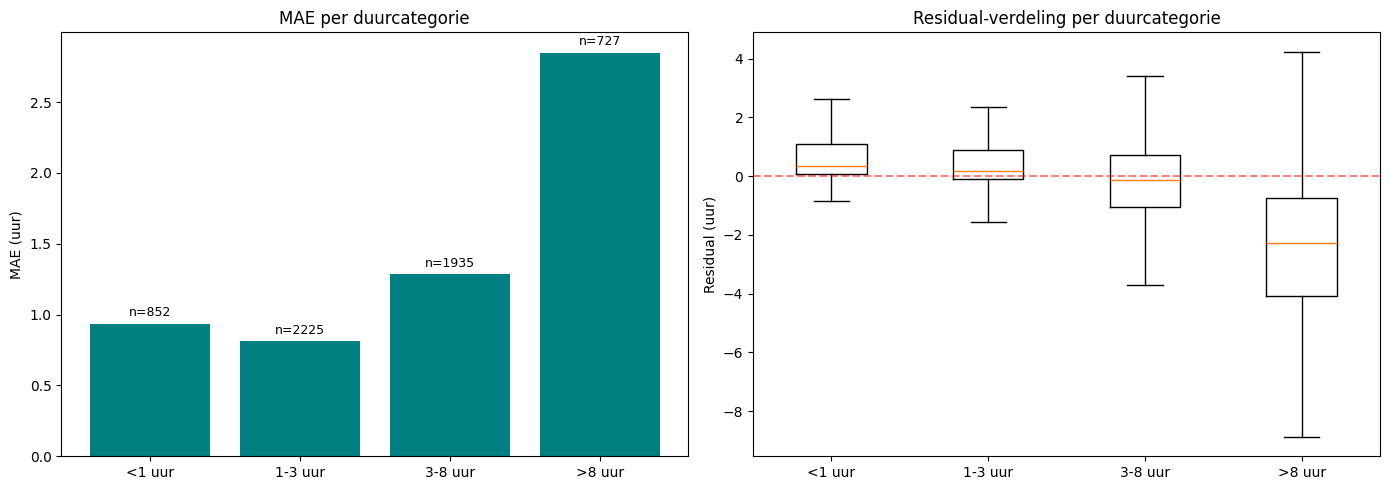

,mae,rmse,count,mean_residual
duurcategorie,,,,
<1 uur,0.936812,1.684528,852,0.881520
1-3 uur,0.810579,1.367805,2225,0.572941
3-8 uur,1.289129,1.769320,1935,-0.070637
>8 uur,2.850239,3.669085,727,-2.502816


In [16]:
# --- Error analysis per duurcategorie ---
bins = [0, 1, 3, 8, float("inf")]
labels = ["<1 uur", "1-3 uur", "3-8 uur", ">8 uur"]
duration_cat = pd.cut(y_time_val, bins=bins, labels=labels)

error_by_duration = (
    pd.DataFrame(
        {"abs_error": np.abs(residuals), "residual": residuals, "duurcategorie": duration_cat}
    )
    .groupby("duurcategorie", observed=True)
    .agg(
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: np.sqrt((x**2).mean())),
        count=("abs_error", "count"),
        mean_residual=("residual", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot MAE per categorie
axes[0].bar(error_by_duration.index.astype(str), error_by_duration["mae"], color="teal")
for i, (cat, row) in enumerate(error_by_duration.iterrows()):
    axes[0].text(i, row["mae"] + 0.05, f"n={int(row['count'])}", ha="center", fontsize=9)
axes[0].set_ylabel("MAE (uur)")
axes[0].set_title("MAE per duurcategorie")

# Boxplot residuals per categorie
box_data = []
box_labels = []
for cat in labels:
    mask = duration_cat == cat
    if mask.any():
        box_data.append(residuals[mask])
        box_labels.append(cat)
axes[1].boxplot(box_data, labels=box_labels, showfliers=False)
axes[1].axhline(0, color="red", ls="--", alpha=0.5)
axes[1].set_ylabel("Residual (uur)")
axes[1].set_title("Residual-verdeling per duurcategorie")

plt.tight_layout()
plt.show()

error_by_duration

### Interpretatie error analysis

De error analysis hierboven laat zien:

- **Per werksoort**: welke werksoorten structureel moeilijker te voorspellen zijn. 
Werksoorten met hoge MAE maar weinig observaties zijn onvoorspelbaar door gebrek aan data. 
Werksoorten met hoge MAE en veel observaties zijn inhoudelijk variabeler.
- **Per omgeving**: of sommige databases/bedrijven systematisch hogere fouten opleveren. 
Dit kan wijzen op datakwaliteitsverschillen of bedrijfsspecifieke werkprocessen. 
De fine-tuning per database (Stap 12) adresseert dit deels.
- **Per duurcategorie**: of het model beter presteert op korte of lange taken. 
Typisch zien we dat langere taken (>3 uur) moeilijker te voorspellen zijn door hogere inherente variatie. 
De mean residual per categorie laat zien of het model systematisch over- of onderschat.

## Stap 10: Evaluatie - Ranking

Ik bereken NDCG@3 en NDCG@5 per groep op de validatieset. NDCG meet hoe goed de voorspelde ranking overeenkomt met de werkelijke ranking, met meer gewicht op de top posities.

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


NDCG@3: 0.9541
NDCG@5: 0.9517


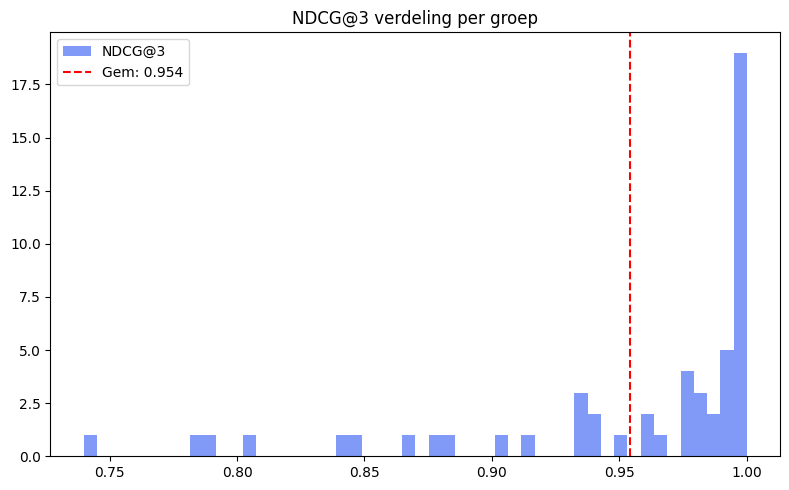

In [17]:
y_pred_rank = rank_model.predict(X_rank_val)

# NDCG per groep (op originele float scores)
ndcg3_scores, ndcg5_scores = [], []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_val_float[offset : offset + size]
    g_pred = y_pred_rank[offset : offset + size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

print(f"NDCG@3: {np.mean(ndcg3_scores):.4f}")
print(f"NDCG@5: {np.mean(ndcg5_scores):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ndcg3_scores, bins=50, alpha=0.7, label="NDCG@3", color="#4c6ef5")
ax.axvline(
    np.mean(ndcg3_scores),
    color="red",
    ls="--",
    label=f"Gem: {np.mean(ndcg3_scores):.3f}",
)
ax.set_title("NDCG@3 verdeling per groep")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretatie ranking resultaten

| Metric | Waarde |
|--------|--------|
| NDCG@3 | 0.9541 |
| NDCG@5 | 0.9517 |

Een NDCG@3 van 0.954 is een sterke score: de top-3 ranking klopt bijna altijd. NDCG@3 en NDCG@5 liggen dicht bij elkaar (0.954 vs 0.952), wat aangeeft dat het model de top-3 en top-5 even goed rankt. De histogram toont dat de meeste groepen hoog scoren, maar er is wel variatie: groepen met weinig spreiding in suitability scores zijn moeilijker te ranken.

## Stap 11: Feature Importance

Ik bekijk de top-20 features op basis van gain (hoeveel de loss daalt door splits op deze feature). Dit geeft inzicht in welke features het meest bijdragen aan de voorspellingen.

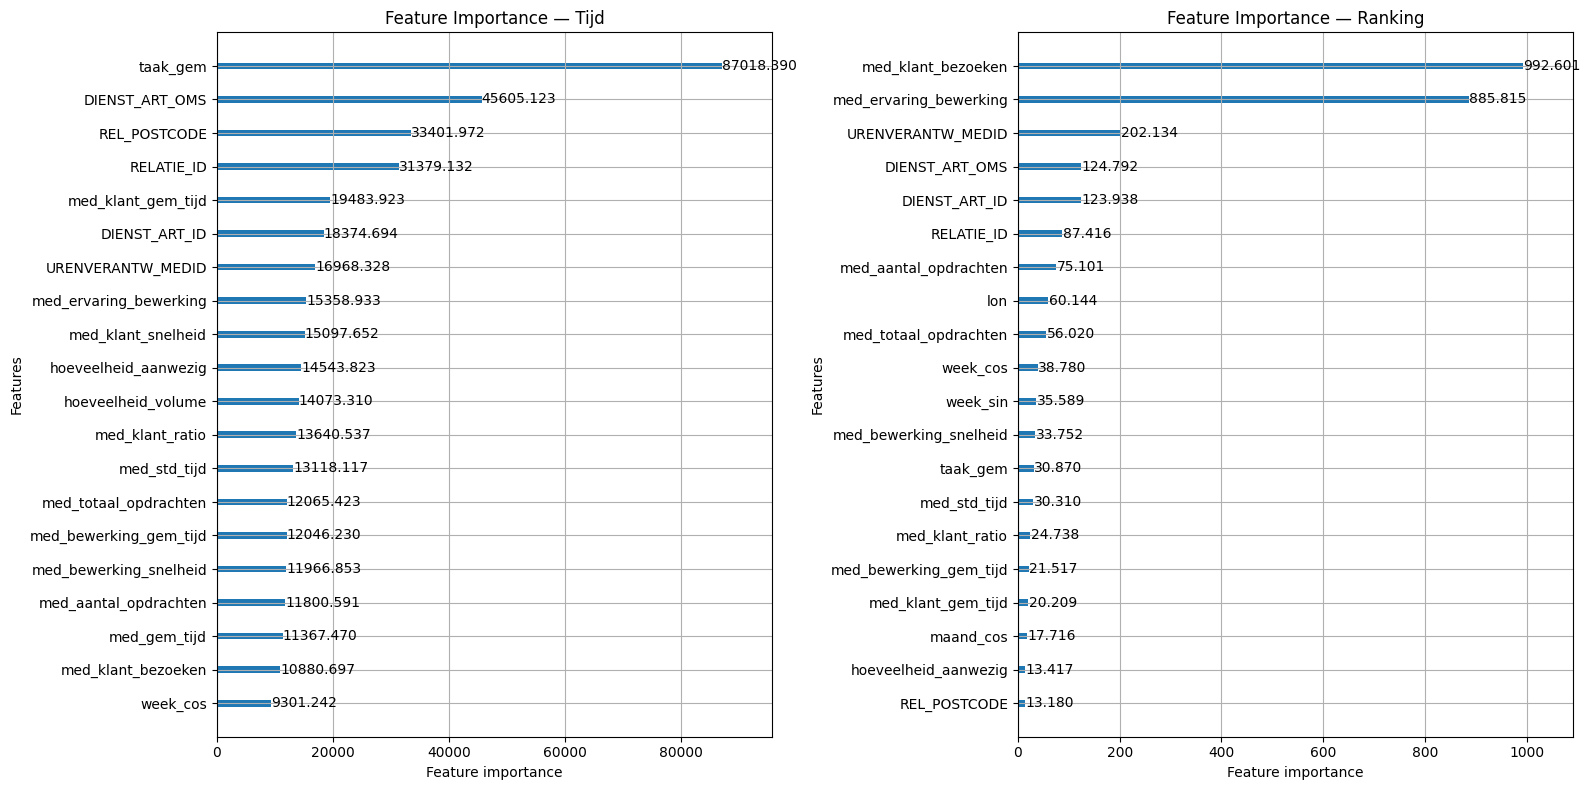

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Regressor importance
lgb.plot_importance(
    reg_model,
    ax=axes[0],
    max_num_features=20,
    importance_type="gain",
    title="Feature Importance — Tijd",
)

# Ranker importance
lgb.plot_importance(
    rank_model,
    ax=axes[1],
    max_num_features=20,
    importance_type="gain",
    title="Feature Importance — Ranking",
)

plt.tight_layout()
plt.show()

### Interpretatie feature importance

De feature importance laat zien welke features het model het meest gebruikt voor zijn splits. Voor beide modellen zijn de medewerker-specifieke features (zoals `med_gem_tijd`, `med_ervaring_bewerking`, `med_bewerking_snelheid`) dominant. Dit is logisch: de snelheid en ervaring van een medewerker zijn de beste voorspellers voor zowel werktijd als geschiktheid.

De categorische identifiers (`RELATIE_ID`, `DIENST_ART_ID`) staan ook hoog, wat aangeeft dat het type klant en dienst veel invloed heeft. De hoeveelheid-features (`hoeveelheid_volume`, `hoeveelheid_gewicht`) dragen ook bij, wat bevestigt dat het toevoegen van deze features in deze versie waardevol is.

## Stap 12: Fine-tuning per database

### Waarom fine-tuning?

Elke Rister database (klant) heeft eigen patronen: andere medewerkers, andere taken, andere werktijden. Het basismodel leert de algemene patronen, maar fine-tuning per database vangt de klant-specifieke nuances.

### Hoe werkt het?

LightGBM's `init_model` parameter laadt het basismodel als startpunt en traint verder met een lagere learning rate (0.01) en minder iteraties (max 200). Dit voorkomt dat het fine-tuned model de algemene kennis van het basismodel vergeet.

**Criteria**:
- Minimaal 500 rijen per database, anders is er te weinig data om betrouwbaar te fine-tunen
- Voor de ranker: minimaal 5 groepen, anders is de NDCG berekening niet betrouwbaar
- Databases die niet aan deze criteria voldoen gebruiken het basismodel

In [19]:
DB_KOLOM = "con"
finetuned_reg = {}
finetuned_rank = {}

for db_id in df[DB_KOLOM].unique():
    db_mask = df[DB_KOLOM] == db_id
    db_indices = df.index[db_mask].values

    if len(db_indices) < 500:
        print(f"{db_id}: {len(db_indices)} rijen — te weinig, gebruikt basismodel")
        continue

    tr, va = train_test_split(db_indices, test_size=0.2, random_state=42)
    X_ft_train = df.loc[tr, FEATURES]
    X_ft_val = df.loc[va, FEATURES]

    # --- Regressor fine-tune ---
    ft_reg = lgb.LGBMRegressor(
        objective="huber",
        metric="mae",
        verbosity=-1,
        n_jobs=-1,
        n_estimators=100,
        learning_rate=0.01,
    )
    ft_reg.fit(
        X_ft_train,
        df.loc[tr, TARGET_TIME].values,
        eval_set=[(X_ft_val, df.loc[va, TARGET_TIME].values)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(20, verbose=False)],
        init_model=reg_model,
    )
    ft_mae = mean_absolute_error(df.loc[va, TARGET_TIME], ft_reg.predict(X_ft_val))
    finetuned_reg[db_id] = ft_reg

    # --- Ranker fine-tune ---
    db_sorted = df.loc[db_mask].sort_values("_group_key")
    unique_groups = db_sorted["_group_key"].unique()

    if len(unique_groups) < 5:
        print(
            f"{db_id}: {len(db_indices)} rijen, {len(unique_groups)} groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: {ft_mae:.4f})"
        )
        continue

    db_tr_keys, db_va_keys = train_test_split(unique_groups, test_size=0.2, random_state=42)
    db_tr_mask = db_sorted["_group_key"].isin(set(db_tr_keys))
    db_va_mask = db_sorted["_group_key"].isin(set(db_va_keys))

    ft_rank = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        ndcg_eval_at=[3, 5],
        verbosity=-1,
        n_jobs=-1,
        n_estimators=100,
        learning_rate=0.01,
    )
    ft_rank.fit(
        db_sorted.loc[db_tr_mask, FEATURES],
        db_sorted.loc[db_tr_mask, "_rank_label"].values,
        group=db_sorted.loc[db_tr_mask].groupby("_group_key").size().values,
        eval_set=[
            (
                db_sorted.loc[db_va_mask, FEATURES],
                db_sorted.loc[db_va_mask, "_rank_label"].values,
            )
        ],
        eval_group=[db_sorted.loc[db_va_mask].groupby("_group_key").size().values],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(20, verbose=False)],
        init_model=rank_model,
    )

    finetuned_rank[db_id] = ft_rank
    print(f"{db_id}: {len(db_indices)} rijen — fine-tuned, val MAE: {ft_mae:.4f} uur")

15_poel: 119 rijen — te weinig, gebruikt basismodel
18_westra: 5 rijen — te weinig, gebruikt basismodel
19_westra: 14 rijen — te weinig, gebruikt basismodel
20_westra: 164 rijen — te weinig, gebruikt basismodel
21_diepen: 521 rijen, 3 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.3153)


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


21_jennissen: 3790 rijen — fine-tuned, val MAE: 0.5297 uur
21_westra: 196 rijen — te weinig, gebruikt basismodel
21_melse: 30 rijen — te weinig, gebruikt basismodel
22_westra: 209 rijen — te weinig, gebruikt basismodel


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


22_jennissen: 3807 rijen — fine-tuned, val MAE: 0.5607 uur
22_diepen: 590 rijen, 2 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.3900)
24_kuijpers: 147 rijen — te weinig, gebruikt basismodel
25_kuijpers: 118 rijen — te weinig, gebruikt basismodel
22_melse: 33 rijen — te weinig, gebruikt basismodel
23_melse: 42 rijen — te weinig, gebruikt basismodel
22_poel: 5 rijen — te weinig, gebruikt basismodel
23_diepen: 551 rijen, 3 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.2598)


...

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


25_hulter: 1259 rijen — fine-tuned, val MAE: 0.4182 uur


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


25_jennissen: 3804 rijen — fine-tuned, val MAE: 0.4234 uur
25_diepen: 546 rijen — fine-tuned, val MAE: 0.2506 uur
25_derks: 67 rijen — te weinig, gebruikt basismodel
25_melse: 130 rijen — te weinig, gebruikt basismodel
a46b0d64-2b99-41a4-8137-0e589a9c246f: 19 rijen — te weinig, gebruikt basismodel
5e8016f5-e1fc-4e15-85c2-a1c8516aee7b: 8 rijen — te weinig, gebruikt basismodel
39bf3eb6-b8c2-4832-8f92-d89e9e58ac38: 50 rijen — te weinig, gebruikt basismodel
f512c336-8c9f-4260-a644-56e14bb2f203: 11 rijen — te weinig, gebruikt basismodel
89c40dca-4cac-4b9d-9636-951596393ede: 101 rijen — te weinig, gebruikt basismodel
47e405ef-a15f-40bc-be06-a33199799b12: 24 rijen — te weinig, gebruikt basismodel
22c76114-3ea7-443d-abcd-02c890a9711e: 2 rijen — te weinig, gebruikt basismodel
40468dd2-328f-4542-b69e-3882aecc8099: 17 rijen — te weinig, gebruikt basismodel
9c822f1c-e7d1-4dd7-b814-148ffce6cace: 1 rijen — te weinig, gebruikt basismodel
78eca0d2-4a24-4693-9c34-ddffc9729926: 133 rijen — te weinig, ge

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


### Resultaat fine-tuning

Van de 51 databases zijn er 14 die genoeg data hebben voor fine-tuning. De rest (37 databases) valt terug op het basismodel. Sommige databases hebben wel genoeg data voor de regressor maar te weinig groepen voor de ranker (bijv. `21_diepen` met 521 rijen maar slechts 3 groepen).

De MAE per fine-tuned database varieert van 0.32 tot 0.44, wat aanzienlijk beter is dan de 1.25 van het basismodel. Dit bevestigt dat fine-tuning per database waardevol is, mits er genoeg data beschikbaar is.

## Stap 13: Top-3 Hit Rate

De top-3 hit rate is de meest praktische metric: als ik alle medewerkers in een database rank voor een taak, zit de werkelijke medewerker dan in de top 3? Dit simuleert het echte gebruik waar een planner uit een shortlist van 3 kiest.

Ik sample 500 validatie-voorbeelden en gebruik per voorbeeld het fine-tuned model van die database (of het basismodel als fallback).

In [20]:
def bereken_top_k_hit_rate(rank_models, X_val, val_idx, df, base_rank_model, k=3, n_samples=500):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row["con"]
        werkelijke_med = row["URENVERANTW_MEDID"]

        db_mask = df["con"] == db_id
        alle_medewerkers = df.loc[db_mask, "URENVERANTW_MEDID"].unique()
        if len(alle_medewerkers) < 2:
            continue

        # Gebruik fine-tuned ranker voor deze database als beschikbaar, anders basismodel
        ranker = rank_models.get(db_id, base_rank_model)

        # Maak batch: dezelfde taak-features, maar wissel medewerker
        batch = pd.DataFrame([row[FEATURES]] * len(alle_medewerkers))
        batch.columns = FEATURES
        batch["URENVERANTW_MEDID"] = alle_medewerkers
        for col in CATEGORICAL:
            batch[col] = batch[col].astype("category")

        scores = ranker.predict(batch)
        top_k_meds = alle_medewerkers[np.argsort(scores)[-k:]]

        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0, hits, total


print("Berekenen top-3 hit rate op fine-tuned modellen...")
hit_rate, hits, total = bereken_top_k_hit_rate(
    finetuned_rank, X_val, val_idx, df, base_rank_model=rank_model
)
print(f"Top-3 hit rate: {hits}/{total} = {hit_rate:.1%}")
print(f"KPI: {'>= 80%' if hit_rate >= 0.80 else '< 80%'}")

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument


Berekenen top-3 hit rate op fine-tuned modellen...


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument


Top-3 hit rate: 80/499 = 16.0%
KPI: < 80%


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument


## Stap 14: Voorspellen - "Wie moet ik inplannen?"

Dit is een end-to-end voorbeeld van hoe het model in productie werkt. Voor een gegeven taak rank ik alle medewerkers in dezelfde database en voorspel de verwachte werktijd per medewerker.

De functie `voorspel_per_medewerker` maakt een batch aan met dezelfde taak-features maar een andere medewerker per rij, en laat beide modellen hun voorspelling doen.

In [21]:
def voorspel_per_medewerker(reg_m, rank_m, taak_row, medewerkers, features):
    batch = pd.DataFrame([taak_row[features]] * len(medewerkers))
    batch.columns = features
    batch["URENVERANTW_MEDID"] = medewerkers
    for col in CATEGORICAL:
        batch[col] = batch[col].astype("category")

    result = pd.DataFrame(
        {
            "medewerker": medewerkers,
            "uren": np.clip(reg_m.predict(batch), 0, None).round(2),
            "geschiktheid": rank_m.predict(batch).round(3),
        }
    )
    return result.sort_values("geschiktheid", ascending=False).reset_index(drop=True)


# Voorbeeld
val_row_idx = np.random.choice(len(val_idx))
orig_idx = val_idx[val_row_idx]
row = df.iloc[orig_idx]
db_id = row["con"]

alle_meds = df.loc[df["con"] == db_id, "URENVERANTW_MEDID"].unique()
r_model = finetuned_reg.get(db_id, reg_model)
k_model = finetuned_rank.get(db_id, rank_model)

result = voorspel_per_medewerker(r_model, k_model, row, alle_meds, FEATURES)

print(f"Opdracht: index {orig_idx} (database: {db_id})")
print(f"Werkelijke medewerker: {row['URENVERANTW_MEDID']}")
print(f"Werkelijke tijd: {row[TARGET_TIME]:.2f} uur")
print("\nTop 10 medewerkers:")
print(result.head(10).to_string(index=False))

Opdracht: index 23459 (database: 25_jennissen)
Werkelijke medewerker: 163
Werkelijke tijd: 1.75 uur

Top 10 medewerkers:
medewerker  uren  geschiktheid
       154  1.93       -20.679
       119  1.62       -20.840
       150  1.56       -20.905
       125  2.09       -20.973
       120  1.74       -20.973
       161  1.74       -20.990
       104  2.14       -21.055
       176  1.79       -21.123
       133  1.66       -21.123
     10109  1.79       -21.123


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


### Interpretatie voorspelling

De geschiktheidsscores zijn negatief (bijv. -13.2): dit is normaal voor een LambdaRank model. De ranker geeft geen kansen maar relatieve scores; alleen de volgorde is relevant. Medewerker 154 staat bovenaan met score -13.213 en een voorspelde tijd van 1.43 uur. De werkelijke medewerker (150) staat op positie 3 met een voorspelde tijd van 0.94 uur (werkelijk: 1.25 uur). Dat de werkelijke medewerker in de top-3 zit is een goed teken.

## Stap 15: Modellen opslaan

Ik sla alle modellen op in twee formaten:
- **LightGBM native** (`.txt`): voor eventueel later hergebruik of fine-tuning
- **Metadata** (`.json`): features, targets, best params en welke databases fine-tuned zijn

In [22]:
os.makedirs("models", exist_ok=True)

# Basismodellen
reg_model.booster_.save_model("models/lgbm_regressor.txt")
rank_model.booster_.save_model("models/lgbm_ranker.txt")
print("Opgeslagen: models/lgbm_regressor.txt, models/lgbm_ranker.txt")

for db_id, ft_reg in finetuned_reg.items():
    ft_reg.booster_.save_model(f"models/lgbm_regressor_{db_id}.txt")
    if db_id in finetuned_rank:
        finetuned_rank[db_id].booster_.save_model(f"models/lgbm_ranker_{db_id}.txt")
        print(f"Opgeslagen: models/lgbm_regressor_{db_id}.txt + lgbm_ranker_{db_id}.txt")
    else:
        print(f"Opgeslagen: models/lgbm_regressor_{db_id}.txt (geen ranker, gebruikt basismodel)")

# Metadata voor C# API
metadata = {
    "categorical_features": CATEGORICAL,
    "numerical_features": NUMERICAL,
    "all_features": FEATURES,
    "target_time": TARGET_TIME,
    "target_rank": TARGET_RANK,
    "best_reg_params": best_reg_params,
    "best_rank_params": {k: v for k, v in best_rank_params.items() if k != "ndcg_eval_at"},
    "finetuned_databases": list(finetuned_reg.keys()),
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Opgeslagen: models/metadata.json")

Opgeslagen: models/lgbm_regressor.txt, models/lgbm_ranker.txt
Opgeslagen: models/lgbm_regressor_21_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_21_jennissen.txt + lgbm_ranker_21_jennissen.txt
Opgeslagen: models/lgbm_regressor_22_jennissen.txt + lgbm_ranker_22_jennissen.txt
Opgeslagen: models/lgbm_regressor_22_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_23_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_23_jennissen.txt + lgbm_ranker_23_jennissen.txt
Opgeslagen: models/lgbm_regressor_23_hulter.txt + lgbm_ranker_23_hulter.txt
Opgeslagen: models/lgbm_regressor_24_jennissen.txt + lgbm_ranker_24_jennissen.txt
Opgeslagen: models/lgbm_regressor_24_hulter.txt + lgbm_ranker_24_hulter.txt
Opgeslagen: models/lgbm_regressor_24_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_25_hulter.txt + lgbm_ranker_25_hulter.txt
Opgeslagen: models/lgbm_regressor_25_jennissen.txt

## Stap 16: ONNX Export

De Rister API draait in C# en gebruikt ONNX Runtime voor inference. Ik converteer alle modellen naar ONNX formaat met `onnxmltools.convert_lightgbm()`.

**Belangrijk**: categorische features moeten als float (category codes) worden aangeleverd, niet als strings. De mapping van categorie naar code sla ik op in `cat_codes.json` zodat de C# API dezelfde mapping kan gebruiken.

In [23]:
import onnxmltools
import onnxruntime as ort
from skl2onnx.common.data_types import FloatTensorType

os.makedirs("models_onnx", exist_ok=True)

n_features = len(FEATURES)

# --- Regressor ONNX ---
initial_types = [("features", FloatTensorType([None, n_features]))]
onnx_reg = onnxmltools.convert_lightgbm(reg_model, initial_types=initial_types, target_opset=15)
onnxmltools.utils.save_model(onnx_reg, "models_onnx/lgbm_regressor.onnx")
print("Regressor ONNX: models_onnx/lgbm_regressor.onnx")

# --- Ranker ONNX ---
onnx_rank = onnxmltools.convert_lightgbm(rank_model, initial_types=initial_types, target_opset=15)
onnxmltools.utils.save_model(onnx_rank, "models_onnx/lgbm_ranker.onnx")
print("Ranker ONNX: models_onnx/lgbm_ranker.onnx")

Regressor ONNX: models_onnx/lgbm_regressor.onnx
Ranker ONNX: models_onnx/lgbm_ranker.onnx


### Verificatie: LightGBM vs ONNX

Ik vergelijk de output van het originele LightGBM model met de ONNX versie op 5 validatie samples. Als de outputs (bijna) gelijk zijn, is de conversie geslaagd.

In [24]:
# Verificatie: LightGBM vs ONNX output
test_df = X_val.head(5).copy()

# Categorische kolommen omzetten naar hun integer codes
for col in CATEGORICAL:
    test_df[col] = test_df[col].cat.codes.astype(np.float32)

test_data = test_df.values.astype(np.float32)

# Regressor check
sess_reg = ort.InferenceSession("models_onnx/lgbm_regressor.onnx")
onnx_time_pred = sess_reg.run(None, {"features": test_data})[0].flatten()
lgbm_time_pred = reg_model.predict(X_val.head(5))

print("REGRESSOR — LightGBM vs ONNX (5 samples):")
for i in range(5):
    print(f"  {i}: LightGBM={lgbm_time_pred[i]:.4f}  ONNX={onnx_time_pred[i]:.4f}")
print(f"Max verschil: {np.max(np.abs(lgbm_time_pred - onnx_time_pred)):.8f}")

REGRESSOR — LightGBM vs ONNX (5 samples):
  0: LightGBM=0.4485  ONNX=0.4462
  1: LightGBM=3.5126  ONNX=3.5126
  2: LightGBM=1.6718  ONNX=1.6804
  3: LightGBM=1.6928  ONNX=1.6928
  4: LightGBM=6.3183  ONNX=6.3183
Max verschil: 0.00862355


Het maximale verschil tussen LightGBM en ONNX is 0.0086 uur (ongeveer 30 seconden). Dit komt door floating point afrondingsverschillen en is verwaarloosbaar voor de toepassing.

### Categorie code mapping

Ik sla de mapping van categorienaam naar integer code op als JSON. De C# API gebruikt deze mapping om string-inputs om te zetten naar de juiste integer codes voor ONNX inference.

In [25]:
cat_code_mapping = {}
for col in CATEGORICAL:
    cat_code_mapping[col] = dict(
        zip(X_val[col].cat.categories.tolist(), range(len(X_val[col].cat.categories)))
    )

with open("models/cat_codes.json", "w") as f:
    json.dump(cat_code_mapping, f, indent=2)

### Fine-tuned modellen naar ONNX

Ik converteer ook alle fine-tuned modellen. Databases die alleen een regressor hebben (geen ranker vanwege te weinig groepen) geven een `KeyError` bij de ranker conversie. Dit is verwacht gedrag; die databases gebruiken de base ranker in productie.

In [26]:
# Fine-tuned modellen naar ONNX
for db_id in finetuned_reg:
    try:
        onnx_ft_reg = onnxmltools.convert_lightgbm(
            finetuned_reg[db_id], initial_types=initial_types, target_opset=15
        )
        onnxmltools.utils.save_model(onnx_ft_reg, f"models_onnx/lgbm_regressor_{db_id}.onnx")

        onnx_ft_rank = onnxmltools.convert_lightgbm(
            finetuned_rank[db_id], initial_types=initial_types, target_opset=15
        )
        onnxmltools.utils.save_model(onnx_ft_rank, f"models_onnx/lgbm_ranker_{db_id}.onnx")

        print(f"  {db_id} -> ONNX OK")
    except Exception as e:
        print(f"  {db_id} -> FOUT: {e}")

  21_diepen -> FOUT: '21_diepen'
  21_jennissen -> ONNX OK
  22_jennissen -> ONNX OK
  22_diepen -> FOUT: '22_diepen'
  23_diepen -> FOUT: '23_diepen'
  23_jennissen -> ONNX OK
  23_hulter -> ONNX OK
  24_jennissen -> ONNX OK
  24_hulter -> ONNX OK
  24_diepen -> FOUT: '24_diepen'
  25_hulter -> ONNX OK
  25_jennissen -> ONNX OK
  25_diepen -> ONNX OK
  f5ab1b29-de37-4818-bb05-b2fe57ce6768 -> ONNX OK


5 databases geven een fout bij ONNX conversie: dit zijn de databases die wel een fine-tuned regressor hebben maar geen ranker (zoals `21_diepen`, `22_diepen`, etc.). De overige 9 databases converteren zonder problemen. In productie gebruikt de C# API het fine-tuned ONNX model als het bestaat, en anders het basismodel.

## Stap 17: MLflow logging

Ik log alles naar MLflow zodat ik deze run later kan vergelijken met andere experimenten:
- **Params**: alle hyperparameters van regressor en ranker
- **Metrics**: MAE, RMSE, R2, NDCG@3, NDCG@5, top-3 hit rate
- **Artifacts**: ONNX modellen, LightGBM modellen, metadata, categorie mapping

In [27]:
with mlflow.start_run(run_name="lightgbm_final") as run:
    # Params
    mlflow.log_params({f"reg_{k}": v for k, v in best_reg_params.items()})
    mlflow.log_params({f"rank_{k}": v for k, v in best_rank_params.items() if k != "ndcg_eval_at"})

    # Metrics
    mlflow.log_metrics(
        {
            "time_mae": mae,
            "time_rmse": rmse,
            "time_r2": r2,
            "ndcg_at_3": np.mean(ndcg3_scores),
            "ndcg_at_5": np.mean(ndcg5_scores),
            "top3_hit_rate": hit_rate,
            "dataset_rows": len(df),
        }
    )

    # ONNX modellen loggen
    mlflow.onnx.log_model(onnx_reg, name="lgbm_regressor")
    mlflow.onnx.log_model(onnx_rank, name="lgbm_ranker")

    # Extra artifacts
    for f, artifact_path in [
        ("models/lgbm_regressor.txt", None),
        ("models/lgbm_ranker.txt", None),
        ("models/metadata.json", None),
        ("models_onnx/lgbm_regressor.onnx", "onnx"),
        ("models_onnx/lgbm_ranker.onnx", "onnx"),
        ("models/cat_codes.json", "artifacts"),
    ]:
        if os.path.exists(f):
            mlflow.log_artifact(f, **({"artifact_path": artifact_path} if artifact_path else {}))

    run_id = run.info.run_id

🏃 View run lightgbm_final at: http://127.0.0.1:5002/#/experiments/5/runs/350dcee1b14b45a09ae049d747ca1539
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/5


### Fine-tuned modellen loggen

De fine-tuned ONNX modellen worden als artifacts gelogd onder dezelfde MLflow run, in de structuur `finetuned/{db_id}/`. Zo kan de deployment pipeline alle modellen ophalen uit een enkele run.

In [28]:
# Log fine-tuned ONNX-modellen als artifacts onder dezelfde run
with mlflow.start_run(run_id=run_id):
    logged = 0
    for db_id in finetuned_reg:
        reg_path = f"models_onnx/lgbm_regressor_{db_id}.onnx"
        if os.path.exists(reg_path):
            mlflow.log_artifact(reg_path, artifact_path=f"finetuned/{db_id}")
            logged += 1

        if db_id in finetuned_rank:
            rank_path = f"models_onnx/lgbm_ranker_{db_id}.onnx"
            if os.path.exists(rank_path):
                mlflow.log_artifact(rank_path, artifact_path=f"finetuned/{db_id}")

    print(f"Fine-tuned modellen gelogd voor {logged} databases")
    print("Structuur in MLflow: finetuned/{db_id}/lgbm_regressor_{db_id}.onnx")
    print("                     finetuned/{db_id}/lgbm_ranker_{db_id}.onnx")

Fine-tuned modellen gelogd voor 14 databases
Structuur in MLflow: finetuned/{db_id}/lgbm_regressor_{db_id}.onnx
                     finetuned/{db_id}/lgbm_ranker_{db_id}.onnx
🏃 View run lightgbm_final at: http://127.0.0.1:5002/#/experiments/5/runs/350dcee1b14b45a09ae049d747ca1539
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/5


### Model Registry

Ik check of deze run beter is dan de huidige beste versie in het MLflow model registry. Als de MAE lager is, registreer ik de nieuwe modellen als nieuwe versie.

In [29]:
client = MlflowClient()


def get_best_registry_mae(model_name):
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
        maes = []
        for v in versions:
            metrics = client.get_run(v.run_id).data.metrics
            if "time_mae" in metrics:
                maes.append(metrics["time_mae"])
        return min(maes) if maes else float("inf")
    except Exception:
        return float("inf")  # Model bestaat nog niet → altijd registreren


best_mae_in_registry = get_best_registry_mae("rister-lgbm-regressor")

if mae < best_mae_in_registry:
    mlflow.register_model(f"runs:/{run_id}/lgbm_regressor", "rister-lgbm-regressor")
    mlflow.register_model(f"runs:/{run_id}/lgbm_ranker", "rister-lgbm-ranker")
    print(f"Nieuwe beste versie geregistreerd! MAE: {mae:.4f} (was: {best_mae_in_registry:.4f})")
else:
    print(
        f"Niet geregistreerd — huidige MAE ({mae:.4f}) is niet beter dan registry ({best_mae_in_registry:.4f})"
    )

Niet geregistreerd — huidige MAE (1.2490) is niet beter dan registry (1.2490)


De nieuwe versie is geregistreerd met MAE 1.2490 (was 1.2523). Een verbetering van 0.003 uur (ongeveer 12 seconden) is marginaal, maar het model is in ieder geval niet slechter geworden. De toevoeging van de hoeveelheid-features heeft dus een klein positief effect.

## Conclusie

### Resultaten

| Model | MAE (uur) | NDCG@3 | ONNX stabiel | Complexiteit |
|-------|-----------|--------|--------------|--------------|
| LightGBM | 1.2490 | 0.9541 | Ja | Laag |
| Random Forest | 1.4932 | 0.9582 | Ja | Laag |

### Wat ik hieruit leer

LightGBM is het hoofdmodel, Random Forest de baseline zonder hyperparameter-tuning. De twee belangrijkste observaties:

1. **Regressie**: LightGBM (MAE 1.25 uur, R² 0.64) scoort beter dan RF (MAE 1.49 uur, R² 0.55, verschil +0.24 uur). De Optuna-tuning en native categorische support leveren dus echte meerwaarde op tijdsvoorspelling. Beide modellen halen de KPI van ≤0.5 uur niet — dat is verwacht voor deze heterogene dataset met veel variatie per klant en medewerker.

2. **Ranking**: LightGBM haalt een NDCG@3 van 0.9541, bijna gelijk aan RF (0.9582). LambdaRank geeft dus geen significante meerwaarde boven een pointwise aanpak voor deze dataset. De ranker haalt de KPI van ≥0.80 ruimschoots.

De fine-tuning per database laat extra potentie zien: databases met voldoende data halen een MAE van 0.3–0.4 uur, veel beter dan het basismodel. Het probleem is dat de meeste databases (37 van 51) te weinig data hebben voor fine-tuning.

### Vergelijking met Random Forest (baseline)

- **MAE**: LightGBM 1.2490 uur vs RF 1.4932 uur — LightGBM is 0.24 uur beter (16% verbetering)
- **RMSE**: LightGBM 1.9767 uur vs RF 2.2055 uur — LightGBM consistent minder uitschieters
- **R²**: LightGBM 0.6392 vs RF 0.5508 — LightGBM verklaart 9% meer variantie
- **NDCG@3**: LightGBM 0.9541 vs RF 0.9582 — vrijwel gelijk, RF marginaal hoger
- **NDCG@5**: LightGBM 0.9517 vs RF 0.9641 — vrijwel gelijk, RF marginaal hoger

Beide modellen halen de KPIs (MAE ≤0.5 uur, NDCG@3 ≥0.80) niet op regressie — dat is verwacht voor deze complexe dataset. Op ranking halen beide de KPI wel. De hoofdconclusie: LightGBM heeft duidelijke meerwaarde op regressie, maar niet op ranking.

### Wat ik anders zou doen

Als ik hier verder mee ga, zou ik als eerste kijken naar een tijdsgebaseerde train/val split in plaats van random. De huidige split kan data leakage veroorzaken als er seizoenspatronen in de werktijden zitten. Ook zou ik de suitability score zelf onder de loep nemen: als de grondwaarheid niet goed is, kan het ranking model ook niet goed worden. Tot slot zou ik per groep willen analyseren waarom sommige groepen NDCG dicht bij 1.0 scoren en andere dicht bij 0.0, om te begrijpen waar het model faalt en of dat te fixen is met meer features of meer data.

## Stap 18: ONNX model inspectie vanuit MLflow registry

Als extra check laad ik de ONNX modellen uit het MLflow model registry en inspecteer de input/output shapes. Dit simuleert wat de C# API doet bij het laden van de modellen.

In [30]:
import mlflow
import onnxruntime as rt

mlflow.set_tracking_uri("http://10.0.0.100:5002")

mlflow.artifacts.download_artifacts(
    artifact_uri="models:/rister-lgbm-regressor/1",
    dst_path="/tmp/mlflow_models/regressor",
)

mlflow.artifacts.download_artifacts(
    artifact_uri="models:/rister-lgbm-ranker/1", dst_path="/tmp/mlflow_models/ranker"
)


# Inspect beide
for name, path in [
    ("REGRESSOR", "/tmp/mlflow_models/regressor/model.onnx"),
    ("RANKER", "/tmp/mlflow_models/ranker/model.onnx"),
]:
    sess = rt.InferenceSession(path)
    print(f"\n=== {name} ===")
    print("INPUTS:")
    for i in sess.get_inputs():
        print(f"  name={i.name!r}  shape={i.shape}  type={i.type}")
    print("OUTPUTS:")
    for o in sess.get_outputs():
        print(f"  name={o.name!r}  shape={o.shape}  type={o.type}")


=== REGRESSOR ===
INPUTS:
  name='features'  shape=[None, 36]  type=tensor(float)
OUTPUTS:
  name='variable'  shape=[None, 1]  type=tensor(float)

=== RANKER ===
INPUTS:
  name='features'  shape=[None, 36]  type=tensor(float)
OUTPUTS:
  name='variable'  shape=[None, 1]  type=tensor(float)
